In [1]:
# this is the copy version of the one in the FMNIST

In [2]:
''' This notebook takes the all the runs and create a file with average of CE_test, CE_train, and accuracy (test) and creates a file called
 averaged_runs_p_0.0_bs_1024 foe all pruning percentage and all the batch size inside the directories. 

 Then based on the file, it will create 6 plots with will combined Avg_CE_test/ Avg_CE_train  vs Batch number for each batch size ( 64, 1024, 60000 ). 

 The plot is named as : CE_Train_Avg_SLP_FMNIST_BS_1024

'''

' This notebook takes the all the runs and create a file with average of CE_test, CE_train, and accuracy (test) and creates a file called\n averaged_runs_p_0.0_bs_1024 foe all pruning percentage and all the batch size inside the directories. \n\n Then based on the file, it will create 6 plots with will combined Avg_CE_test/ Avg_CE_train  vs Batch number for each batch size ( 64, 1024, 60000 ). \n\n The plot is named as : CE_Train_Avg_SLP_FMNIST_BS_1024\n\n'

In [1]:
# import pandas as pd
# import glob
# import os
# import matplotlib.pyplot as plt

# # =========================
# # CONFIG
# # =========================
# BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"
# BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
# FILE_PATTERN = "slp_{:.1f}_{}_run_*"

# BATCH_SIZES = [64, 1024, 60000]

# # =========================
# # STYLE (Nature-like)
# # =========================
# plt.rcParams.update({
#     "font.size": 18,
#     "axes.titlesize": 18,
#     "axes.labelsize": 18,
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 15
# })

# # =========================
# # LOOP OVER BATCH SIZES
# # =========================
# for bs in BATCH_SIZES:
#     all_avg_dfs = {}

#     for p in [round(x * 0.1, 1) for x in range(0, 11)]:
#         folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
#         pattern = FILE_PATTERN.format(p, bs)
#         files = glob.glob(os.path.join(folder, pattern))

#         if not files:
#             print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
#             continue

#         # =========================
#         # LOAD ALL RUNS
#         # =========================
#         dfs = []
#         for f in files:
#             df = pd.read_csv(f, sep=r"\s+")
#             df.columns = df.columns.str.strip()

#             df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
#             df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
#             df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

#             dfs.append(df)

#         all_runs = pd.concat(dfs, ignore_index=True)

#         # =========================
#         # GROUP + AVERAGE
#         # =========================
#         avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
#             Avg_CE_Train=("CE_Train", "mean"),
#             Avg_CE_Test=("CE_TEST", "mean"),
#             Avg_Accuracy=("Accuracy(%)", "mean"),
#             Num_Runs=("CE_TEST", "count")
#         )

#         # =========================
#         # SAVE CSV
#         # =========================
#         out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
#         avg_df.to_csv(out_csv, index=False)

#         all_avg_dfs[p] = avg_df

#     # =========================
#     # COMBINED PLOT (CE_Train)
#     # =========================
#     plt.figure(figsize=(12, 6))

#     for p, avg_df in all_avg_dfs.items():
#         plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"], label=f"P%={round(p * 100)}")

#     plt.xlabel("Batch Number")
#     plt.ylabel("Average CE")

#     plt.ylim(0, 2.5)
#     plt.yticks([x * 0.25 for x in range(0, 11)])

#     plt.text(0.50, 0.95, "Cross-Entropy",
#              transform=plt.gca().transAxes, va="top", ha="center")
#     plt.text(0.50, 0.90,
#              f"(SLP Average of FMNIST Training-Vectors, BS={bs})",
#              transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

#     handles, labels = plt.gca().get_legend_handles_labels()
#     plt.legend(handles[::-1], labels[::-1],
#                loc="upper right",
#                bbox_to_anchor=(1.0, 1.02),
#                frameon=False)

#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"CE_Train_Avg_SLP_FMNIST_BS_{bs}.png",
#                 bbox_inches="tight", dpi=300)
#     plt.show()

#     # =========================
#     # COMBINED PLOT (CE_Test)
#     # =========================
#     plt.figure(figsize=(12, 6))

#     for p, avg_df in all_avg_dfs.items():
#         plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"P%={round(p * 100)}")

#     plt.xlabel("Batch Number")
#     plt.ylabel("Average CE")

#     plt.ylim(0, 2.5)
#     plt.yticks([x * 0.25 for x in range(0, 11)])

#     plt.text(0.50, 0.95, "Cross-Entropy",
#              transform=plt.gca().transAxes, va="top", ha="center")
#     plt.text(0.50, 0.90,
#              f"(SLP Average of FMNIST Test-Vectors, BS={bs})",
#              transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

#     handles, labels = plt.gca().get_legend_handles_labels()
#     plt.legend(handles[::-1], labels[::-1],
#                loc="upper right", frameon=False)

#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"CE_Test_Avg_SLP_FMNIST_BS_{bs}.png",
#                 bbox_inches="tight", dpi=300)
#     plt.show()

#     # =========================
#     # COMBINED PLOT (Accuracy)
#     # =========================
#     plt.figure(figsize=(12, 6))

#     for p, avg_df in all_avg_dfs.items():
#         plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"], label=f"P%={round(p * 100)}")

#     plt.xlabel("Batch Number")
#     plt.ylabel("Average Accuracy (%)")

#     plt.ylim(0, 100)
#     plt.yticks(range(0, 101, 10))

#     plt.text(0.50, 0.55, "Accuracy",
#              transform=plt.gca().transAxes, va="top", ha="center")
#     plt.text(0.50, 0.50,
#              f"(SLP Average of FMNIST Test-Vectors, BS={bs})",
#              transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

#     plt.legend(loc="lower right",
#                bbox_to_anchor=(1.0, 0.1),
#                frameon=False)

#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"Accuracy_Avg_SLP_FMNIST_BS_{bs}.png",
#                 bbox_inches="tight", dpi=300)
#     plt.show()


In [2]:
#FInal version color coded:

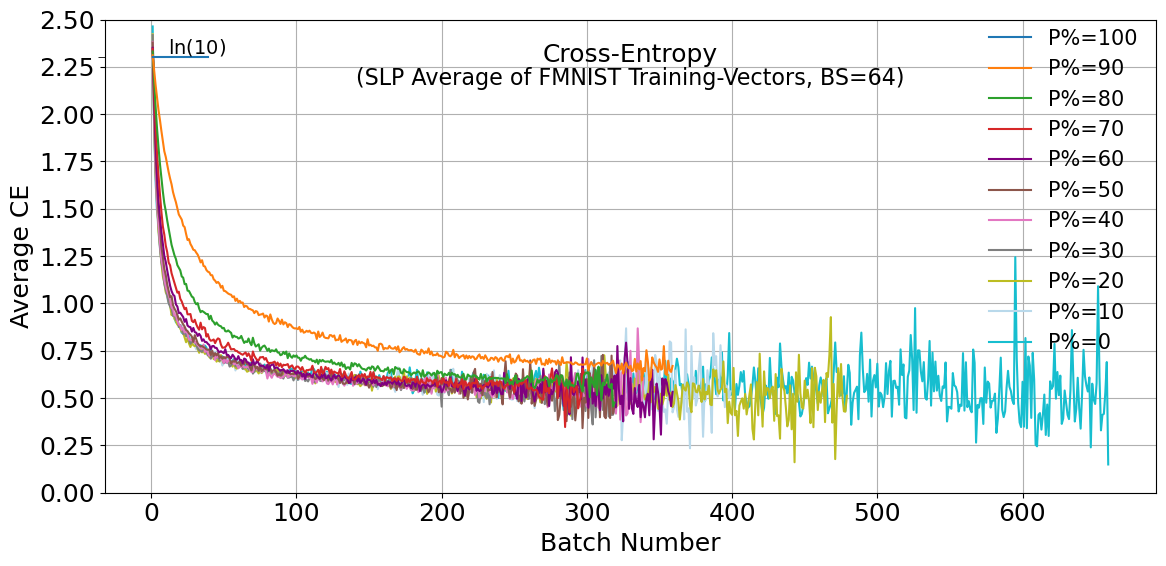

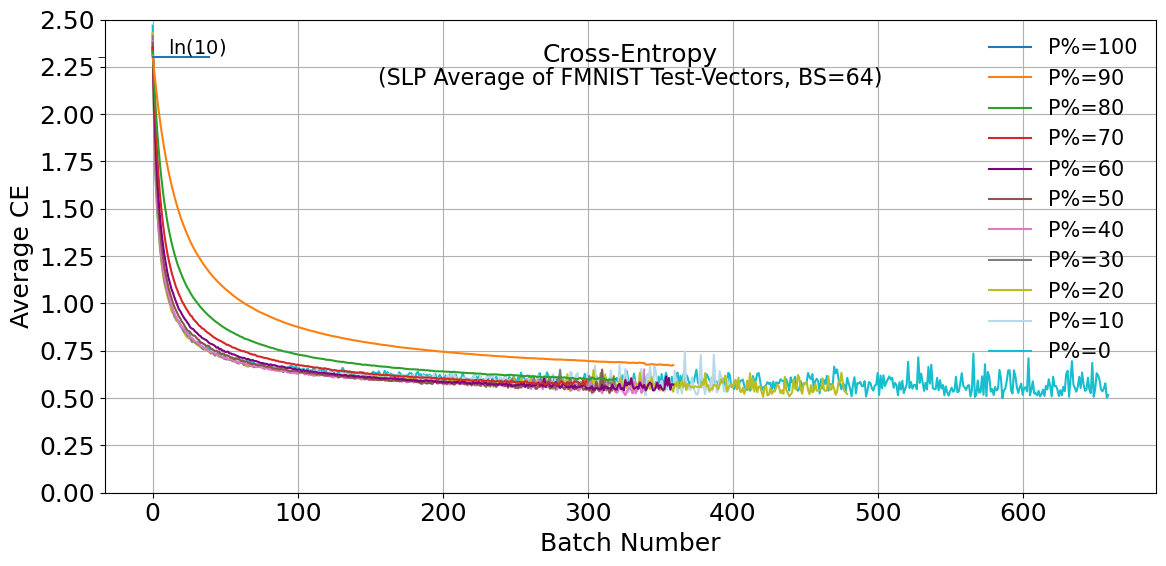

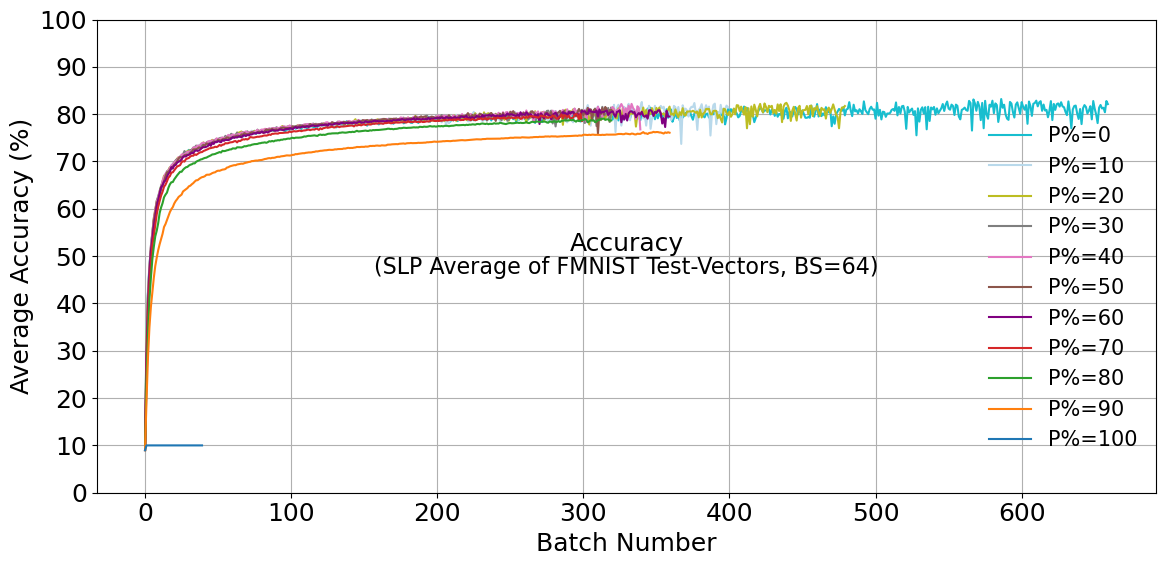

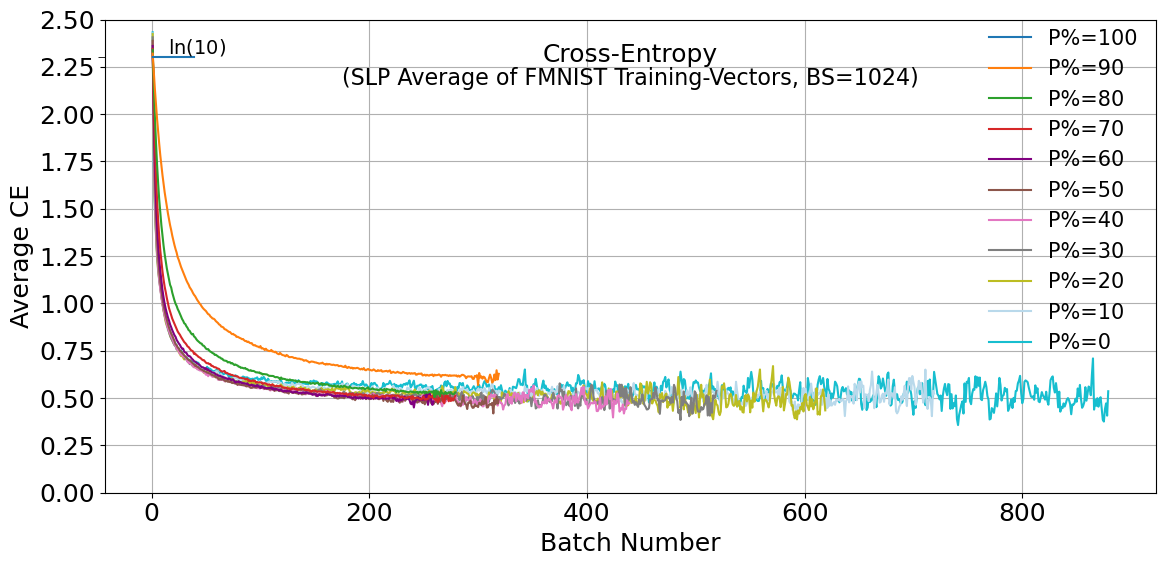

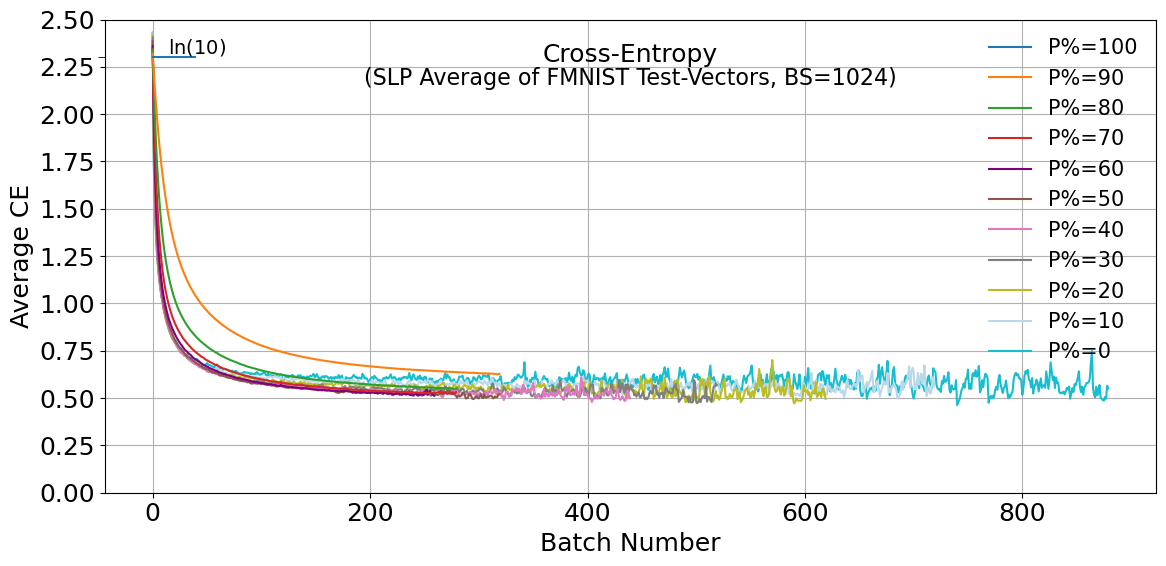

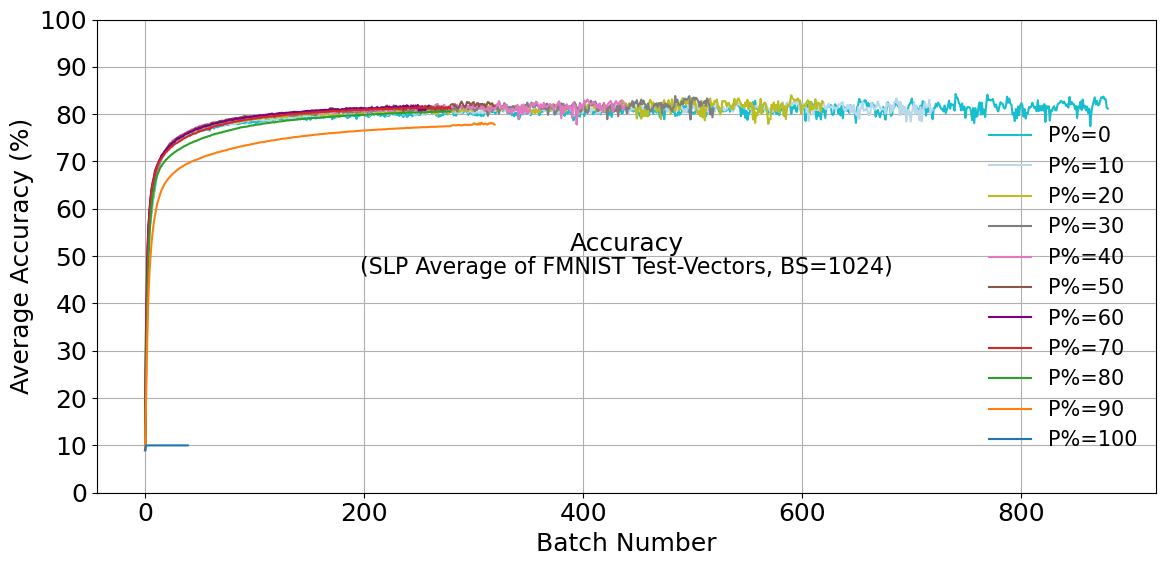

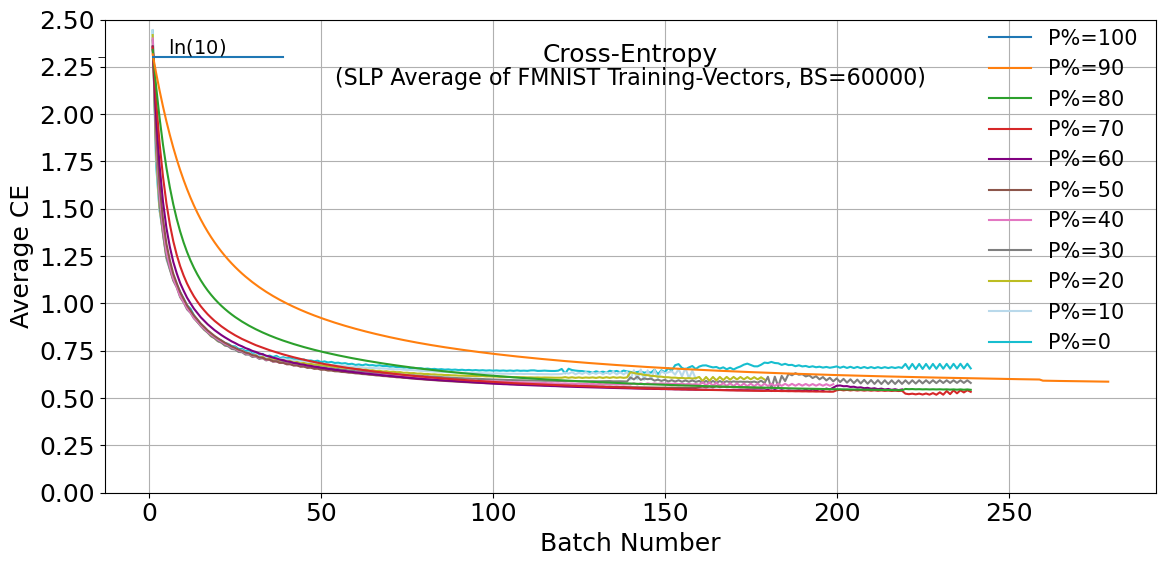

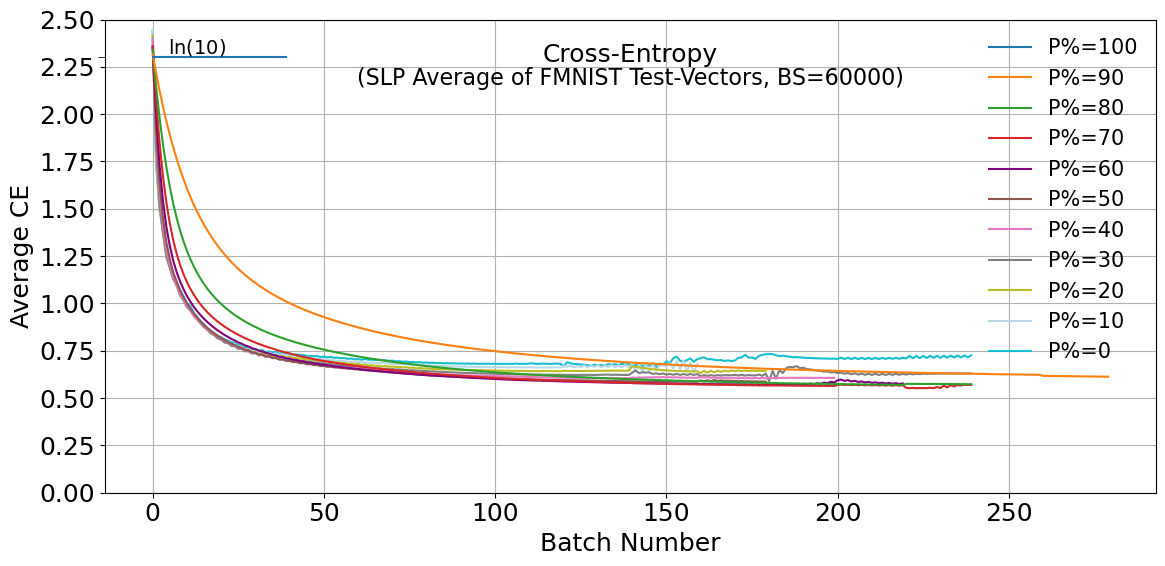

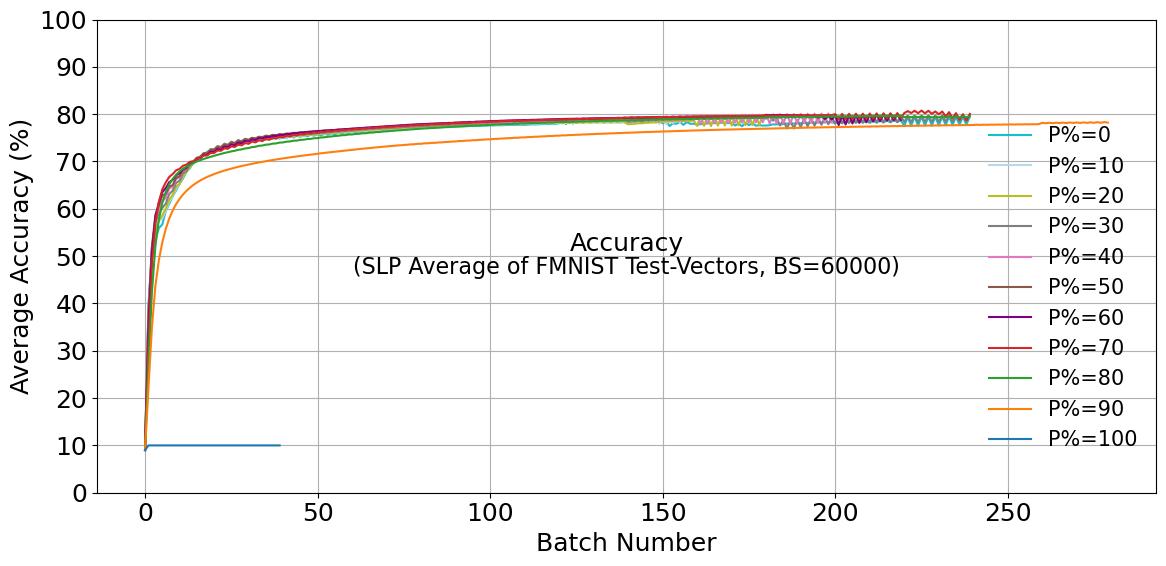

In [4]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
FILE_PATTERN = "slp_{:.1f}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]

LN10 = np.log(10)

# =========================
# DEFINE COLORS FOR PERCENTAGES
# =========================
COLOR_LIST = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#800080",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#B9D9EB", "#17becf"]

COLOR_LIST = COLOR_LIST[::-1] # need to reverse the order for plotting just the average, not required for AUC( Area under the curve ) 


# =========================
# STYLE (Nature-like)
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15
})

# =========================
# LOOP OVER BATCH SIZES
# =========================
for bs in BATCH_SIZES:
    all_avg_dfs = {}

    for idx, p in enumerate([round(x * 0.1, 1) for x in range(0, 11)]):
        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
            continue

        # =========================
        # LOAD ALL RUNS
        # =========================
        dfs = []
        for f in files:
            df = pd.read_csv(f, sep=r"\s+")
            df.columns = df.columns.str.strip()

            df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
            df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
            df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

            dfs.append(df)

        all_runs = pd.concat(dfs, ignore_index=True)

        # =========================
        # GROUP + AVERAGE
        # =========================
        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        # =========================
        # SAVE CSV
        # =========================
        out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
        avg_df.to_csv(out_csv, index=False)

        all_avg_dfs[p] = avg_df

    # =========================
    # COMBINED PLOT (CE_Train)
    # =========================
    plt.figure(figsize=(12, 6))
    for idx, (p, avg_df) in enumerate(all_avg_dfs.items()):
        color = COLOR_LIST[idx % len(COLOR_LIST)]
        plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"], label=f"P%={round(p * 100)}", color=color)

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.06, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")

    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5, color='black')

    plt.text(0.50, 0.95, "Cross-Entropy", transform=plt.gca().transAxes, va="top", ha="center")
    plt.text(0.50, 0.90, f"(SLP Average of FMNIST Training-Vectors, BS={bs})",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[::-1], labels[::-1],
               loc="upper right", bbox_to_anchor=(1.0, 1.02), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"CE_Train_Avg_SLP_FMNIST_BS_{bs}.png",
                bbox_inches="tight", dpi=300)
    plt.show()

    # =========================
    # COMBINED PLOT (CE_Test)
    # =========================
    plt.figure(figsize=(12, 6))
    for idx, (p, avg_df) in enumerate(all_avg_dfs.items()):
        color = COLOR_LIST[idx % len(COLOR_LIST)]
        plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"P%={round(p * 100)}", color=color)

    plt.xlabel("Batch Number")
    plt.ylabel("Average CE")
    plt.ylim(0, 2.5)
    plt.yticks([x * 0.25 for x in range(0, 11)])

    plt.text(0.06, LN10 + 0.05, r"$\ln(10)$",
             transform=plt.gca().get_yaxis_transform(),
             fontsize=14, va="center", ha="left")

    plt.gca().yaxis.set_minor_locator(plt.FixedLocator([LN10]))
    plt.tick_params(axis='y', which='minor', length=5, color='black')

    plt.text(0.50, 0.95, "Cross-Entropy", transform=plt.gca().transAxes, va="top", ha="center")
    plt.text(0.50, 0.90, f"(SLP Average of FMNIST Test-Vectors, BS={bs})",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[::-1], labels[::-1], loc="upper right", frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"CE_Test_Avg_SLP_FMNIST_BS_{bs}.png",
                bbox_inches="tight", dpi=300)
    plt.show()

    # =========================
    # COMBINED PLOT (Accuracy)
    # =========================
    plt.figure(figsize=(12, 6))
    for idx, (p, avg_df) in enumerate(all_avg_dfs.items()):
        color = COLOR_LIST[idx % len(COLOR_LIST)]
        plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"], label=f"P%={round(p * 100)}", color=color)

    plt.xlabel("Batch Number")
    plt.ylabel("Average Accuracy (%)")
    plt.ylim(0, 100)
    plt.yticks(range(0, 101, 10))

    plt.text(0.50, 0.55, "Accuracy", transform=plt.gca().transAxes, va="top", ha="center")
    plt.text(0.50, 0.50, f"(SLP Average of FMNIST Test-Vectors, BS={bs})",
             transform=plt.gca().transAxes, va="top", ha="center", fontsize=16)

    plt.legend(loc="lower right", bbox_to_anchor=(1.0, 0.05), frameon=False)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Accuracy_Avg_SLP_FMNIST_BS_{bs}.png",
                bbox_inches="tight", dpi=300)
    plt.show()
